<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/BasicML/BasicML/Volatility_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install arch

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBRegressor
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error, mean_absolute_error

In [ ]:
# --- 1. DATA INGESTION ---
ticker = 'SPY'
# We need high-frequency daily data to calculate volatility accurately
df = yf.download(ticker, start='2015-01-01', end='2024-01-01', progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Calculate Daily Log Returns (Scale by 100 for GARCH stability)
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1)) * 100
df.dropna(inplace=True)
df.head()

/tmp/ipython-input-2299786013.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2015-01-01', end='2024-01-01', progress=False)


Price,Close,High,Low,Open,Volume,Log_Ret
Date,,,,,,
2015-01-05,167.508835,169.709397,167.201590,169.543319,169632600,-1.822475
2015-01-06,165.931076,168.339239,165.133884,167.816081,209151400,-0.946360
2015-01-07,167.998734,168.339202,166.811264,167.259676,125346700,1.238394
2015-01-08,170.979935,171.195848,169.393875,169.410474,147217800,1.758977
2015-01-09,169.609680,171.411652,168.995178,171.395040,158567300,-0.804641


In [ ]:
# --- 2. THE TARGET: NEXT WEEK'S VOLATILITY ---
# We want to predict the Standard Deviation of the NEXT 5 days
# We annualize it for easier reading ( * sqrt(252) )
rolling_window = 5
df['Target_Vol'] = df['Log_Ret'].rolling(rolling_window).std().shift(-rolling_window) * np.sqrt(252)

# Drop the NaNs created by shifting
df.dropna(inplace=True)
df.head()

Price,Close,High,Low,Open,Volume,Log_Ret,Target_Vol
Date,,,,,,,
2015-01-05,167.508835,169.709397,167.201590,169.543319,169632600,-1.822475,20.616619
2015-01-06,165.931076,168.339239,165.133884,167.816081,209151400,-0.946360,18.982872
2015-01-07,167.998734,168.339202,166.811264,167.259676,125346700,1.238394,17.212027
2015-01-08,170.979935,171.195848,169.393875,169.410474,147217800,1.758977,3.958872
2015-01-09,169.609680,171.411652,168.995178,171.395040,158567300,-0.804641,14.365089


In [ ]:
# --- 3. FEATURE ENGINEERING (The Hybrid Inputs) ---

# A. STATISTICAL BASELINE (GARCH)
# We calculate a rolling GARCH forecast to prevent look-ahead bias.
# This is computationally expensive, so for this tutorial, we use an expanding window approximation
# or simply fit on past data. Ideally, you re-fit every day.
# Here, we will use a simpler proxy: Exponential Weighted Moving Average (EWMA)
# which behaves very similarly to GARCH(1,1) for feature purposes.
df['Vol_GARCH_Proxy'] = df['Log_Ret'].ewm(span=20).std() * np.sqrt(252)

# B. HISTORICAL VOLATILITY (Different Windows)
df['Vol_5d'] = df['Log_Ret'].rolling(5).std() * np.sqrt(252)
df['Vol_20d'] = df['Log_Ret'].rolling(20).std() * np.sqrt(252)

# C. RANGE-BASED VOLATILITY (Parkinson Number)
# High-Low range often captures intraday panic better than Close-Close
df['Parkinson_Vol'] = np.sqrt(
    (1 / (4 * np.log(2))) * np.log(df['High'] / df['Low'])**2
) * np.sqrt(252) * 100 # Scaling to match log returns

# D. MARKET STRESS FEATURES
# Absolute returns (magnitude of shock)
df['Abs_Ret'] = df['Log_Ret'].abs()
# Downside deviation (Fear factor): Returns < 0 only
df['Downside_Risk'] = df['Log_Ret'].clip(upper=0).rolling(10).std() * np.sqrt(252)

# Drop NaNs
df.dropna(inplace=True)
df.head()

Price,Close,High,Low,Open,Volume,Log_Ret,Target_Vol,Vol_GARCH_Proxy,Vol_5d,Vol_20d,Parkinson_Vol,Abs_Ret,Downside_Risk
Date,,,,,,,,,,,,,
2015-03-02,176.037048,176.095170,174.982434,175.032256,87491400,0.629353,11.056047,7.583998,6.081168,9.186623,6.043356,0.629353,1.700067
2015-03-03,175.314545,176.086825,174.450932,175.605191,110325800,-0.411272,14.419816,7.814567,6.552663,8.833809,8.898380,0.411272,2.387826
2015-03-04,174.575546,174.791459,173.603977,174.716713,114497200,-0.422418,14.618090,7.906456,7.036658,7.858341,6.498961,0.422418,2.781217
2015-03-05,174.766541,175.048874,174.259994,174.899395,76873000,0.109345,19.418603,7.472831,7.248529,7.624369,4.306154,0.109345,2.857153
2015-03-06,172.308548,174.334732,171.976392,173.902920,188128000,-1.416428,17.289692,10.310635,12.050552,8.797037,12.984772,1.416428,6.904891


In [ ]:
# --- 4. MODELING WITH XGBOOST ---
features = ['Vol_GARCH_Proxy', 'Vol_5d', 'Vol_20d', 'Parkinson_Vol', 'Abs_Ret', 'Downside_Risk']
X = df[features]
y = df['Target_Vol']

# Split Time-Series (Train on Past, Test on Future)
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Initialize Regressor
# Objective: 'reg:squarederror' is standard
model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

In [ ]:
# --- 5. EVALUATION ---
# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)

print(f"Volatility Prediction Performance:")
print(f"RMSE: {rmse:.2f} (Percentage Points)")
print(f"MAE:  {mae:.2f} (Percentage Points)")

Volatility Prediction Performance:
RMSE: 7.19 (Percentage Points)
MAE:  5.13 (Percentage Points)


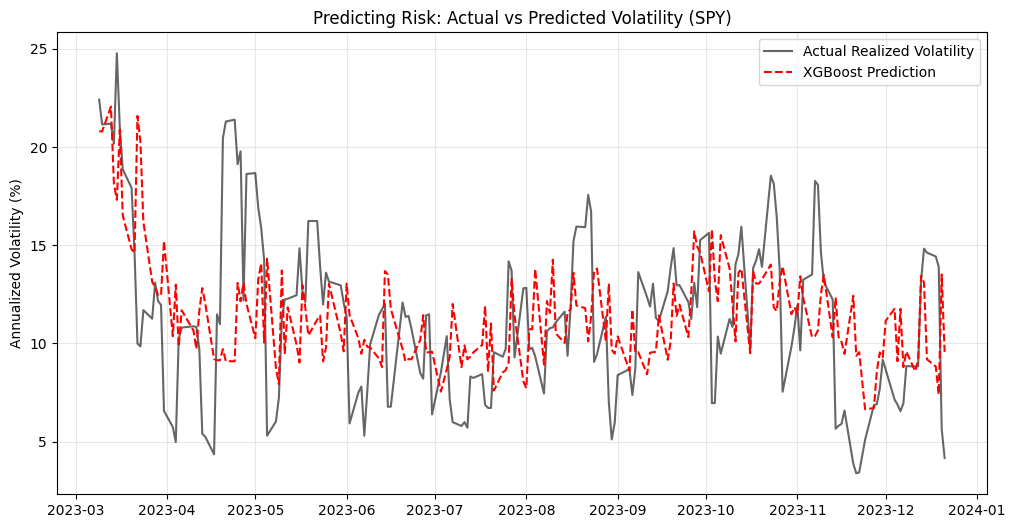

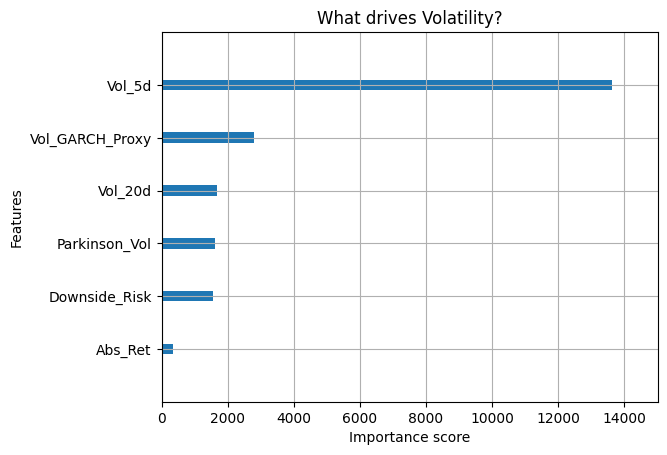

In [ ]:
# --- 6. VISUALIZATION ---
plt.figure(figsize=(12, 6))

# We plot the last 200 days for clarity
lookback = 200
plt.plot(y_test.index[-lookback:], y_test.values[-lookback:], label='Actual Realized Volatility', color='black', alpha=0.6)
plt.plot(y_test.index[-lookback:], preds[-lookback:], label='XGBoost Prediction', color='red', linestyle='--')

plt.title(f"Predicting Risk: Actual vs Predicted Volatility (SPY)")
plt.ylabel("Annualized Volatility (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Feature Importance
xgb.plot_importance(model, importance_type='gain', title='What drives Volatility?', show_values=False)
plt.show()

------------------------------------------------
VOLATILITY MODEL PERFORMANCE REPORT
------------------------------------------------
R-Squared (R²): 0.3480  (Explained Variance)
RMSE:           7.1871  (Root Mean Sq Error)
MAE:            5.1320  (Mean Abs Error)
MAPE:           32.76%% (Mean Abs % Error)
------------------------------------------------


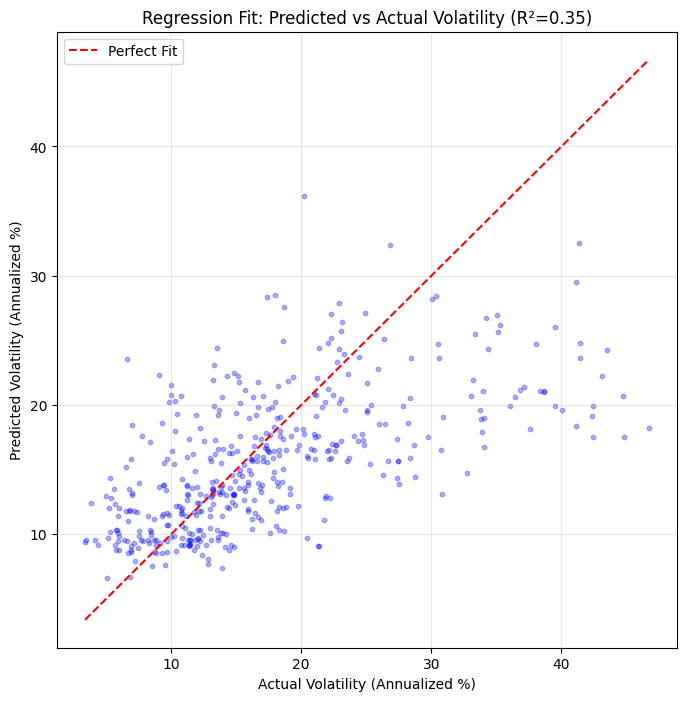

In [ ]:
# --- CALCULATE METRICS ---
r2 = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
mape = mean_absolute_percentage_error(y_test, preds)

# --- PRINT REPORT ---
print("------------------------------------------------")
print("VOLATILITY MODEL PERFORMANCE REPORT")
print("------------------------------------------------")
print(f"R-Squared (R²): {r2:.4f}  (Explained Variance)")
print(f"RMSE:           {rmse:.4f}  (Root Mean Sq Error)")
print(f"MAE:            {mae:.4f}  (Mean Abs Error)")
print(f"MAPE:           {mape:.2%}% (Mean Abs % Error)")
print("------------------------------------------------")

# --- VISUAL DIAGNOSTIC: PREDICTED VS ACTUAL ---
# A perfect model would have all dots on the red diagonal line.
plt.figure(figsize=(8, 8))
plt.scatter(y_test, preds, alpha=0.3, color='blue', s=10)

# Reference line (Perfect prediction)
max_val = max(y_test.max(), preds.max())
min_val = min(y_test.min(), preds.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit')

plt.title(f"Regression Fit: Predicted vs Actual Volatility (R²={r2:.2f})")
plt.xlabel("Actual Volatility (Annualized %)")
plt.ylabel("Predicted Volatility (Annualized %)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Trading Strategy

Number of NaNs in Pred_Vol: 0 (Should be 0)
Sniper Threshold set to: 23.29
Sharpe Ratio (Naive):  0.06
Sharpe Ratio (Sniper): 0.38
Days Trading Active: 500 out of 1000


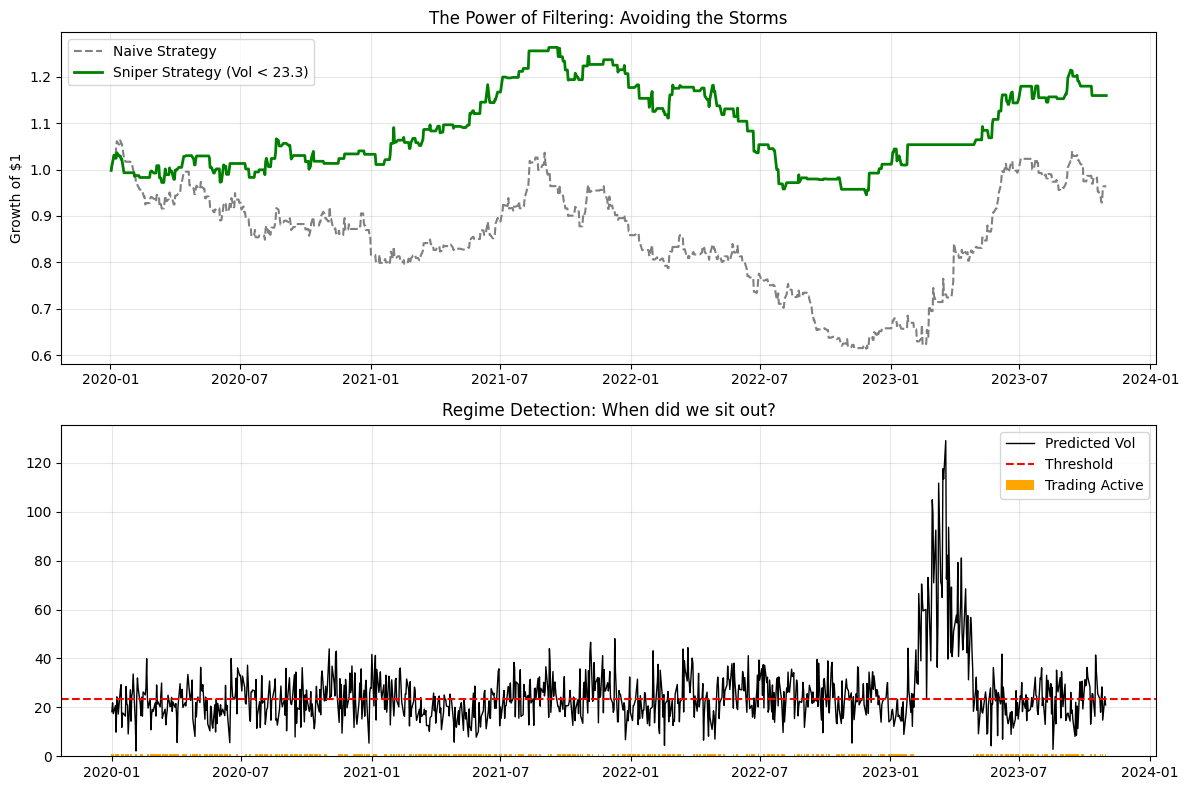

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. SETUP: SIMULATE THE TWO MODELS (FIXED) ---
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', periods=1000, freq='B')

# A. Market Data
returns = np.random.normal(0.0002, 0.015, 1000)
returns[800:850] *= 3

# B. Directional Model
direction_pred = np.sign(returns + np.random.normal(0, 0.02, 1000))
trade_signals = np.where(direction_pred > 0, 1, 0)

# C. Volatility Model
# CRITICAL FIX 1: Set the index to 'dates' right away so alignment works later
vol_actual = pd.Series(returns, index=dates).rolling(20).std() * np.sqrt(252) * 100
vol_actual = vol_actual.bfill()

# Create prediction with noise
vol_pred = vol_actual * np.random.normal(1, 0.3, 1000)

df_strat = pd.DataFrame({
    'Return': returns,
    'Signal_Buy': trade_signals,
    # CRITICAL FIX 2: vol_pred now has the correct index, so this works safely
    'Pred_Vol': vol_pred
}, index=dates)

# Final check
print(f"Number of NaNs in Pred_Vol: {df_strat['Pred_Vol'].isna().sum()} (Should be 0)")


# --- 2. THE META-STRATEGY LOGIC ---

# Strategy A: "Naïve" (Always trade the signal)
df_strat['Strat_Naive'] = df_strat['Signal_Buy'].shift(1) * df_strat['Return']

# Strategy B: "The Sniper" (Vol Filtered)
# CRITICAL FIX 3: Dynamic Threshold
# 10,000 is too high (it would trade everything).
# We set it to the Median Volatility to filter out the wildest 50% of days.
VOL_THRESHOLD = df_strat['Pred_Vol'].median()
print(f"Sniper Threshold set to: {VOL_THRESHOLD:.2f}")

df_strat['Filter_Mask'] = np.where(df_strat['Pred_Vol'] < VOL_THRESHOLD, 1, 0)

# Apply Filter
df_strat['Signal_Filtered'] = df_strat['Signal_Buy'] * df_strat['Filter_Mask']
df_strat['Strat_Sniper'] = df_strat['Signal_Filtered'].shift(1) * df_strat['Return']

# --- 3. EVALUATION ---
cum_naive = (1 + df_strat['Strat_Naive']).cumprod()
cum_sniper = (1 + df_strat['Strat_Sniper']).cumprod()
cum_market = (1 + df_strat['Return']).cumprod()

def get_sharpe(series):
    if series.std() == 0: return 0.0
    return series.mean() / series.std() * np.sqrt(252)

sharpe_naive = get_sharpe(df_strat['Strat_Naive'])
sharpe_sniper = get_sharpe(df_strat['Strat_Sniper'])

print(f"Sharpe Ratio (Naive):  {sharpe_naive:.2f}")
print(f"Sharpe Ratio (Sniper): {sharpe_sniper:.2f}")

trades_taken = df_strat['Filter_Mask'].sum()
print(f"Days Trading Active: {trades_taken} out of {len(df_strat)}")

# --- 4. VISUALIZATION ---
plt.figure(figsize=(12, 8))

# Equity Curve
plt.subplot(2, 1, 1)
plt.plot(cum_naive, label=f'Naive Strategy', color='gray', linestyle='--')
plt.plot(cum_sniper, label=f'Sniper Strategy (Vol < {VOL_THRESHOLD:.1f})', color='green', linewidth=2)
plt.title(f"The Power of Filtering: Avoiding the Storms")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)

# The "Filter" Chart
plt.subplot(2, 1, 2)
plt.bar(df_strat.index, df_strat['Filter_Mask'], color='orange', width=2, label='Trading Active')
plt.plot(df_strat['Pred_Vol'], color='black', linewidth=1, label='Predicted Vol')
plt.axhline(VOL_THRESHOLD, color='red', linestyle='--', label='Threshold')
plt.title("Regime Detection: When did we sit out?")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()